## Solubility datasets

### Solubility dataset by Cui et al

Cui Q, Lu S, Ni B, Zeng X, Tan Y, Chen YD and Zhao H (2020) Improved Prediction of Aqueous Solubility of Novel Compounds by Going Deeper With Deep Learning. Front. Oncol. 10:121. doi: 10.3389/fonc.2020.00121

In [15]:
import pandas as pd
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

NOTEBOOK_DIR = Path.cwd()
REPO_ROOT = NOTEBOOK_DIR.parents[1]

solubility_data1 = pd.read_csv(REPO_ROOT / "external" / "grover" / "solubility_data" / "cui_et_al.csv")
solubility_data1 = solubility_data1.dropna()

duplicates_inchi = solubility_data1.duplicated(subset=["InChIKey"])
print(f"Number of duplicated inchikeys: {duplicates_inchi.sum()}")

duplicates_smiles = solubility_data1.duplicated(subset=["SMILES"])
print(f"Number of duplicated SMILES: {duplicates_smiles.sum()}")

solubility_data_unique1 = solubility_data1.drop_duplicates(subset=["InChIKey"], keep="first")
solubility_data_unique1 = solubility_data_unique1.drop_duplicates(subset=["SMILES"], keep="first")

solubility_data_unique1 = solubility_data_unique1.reset_index(drop=True)

print(f"Original rows: {len(solubility_data1)}")
print(f"Rows after removing duplicates: {len(solubility_data_unique1)}")

Number of duplicated inchikeys: 2
Number of duplicated SMILES: 0
Original rows: 9943
Rows after removing duplicates: 9941


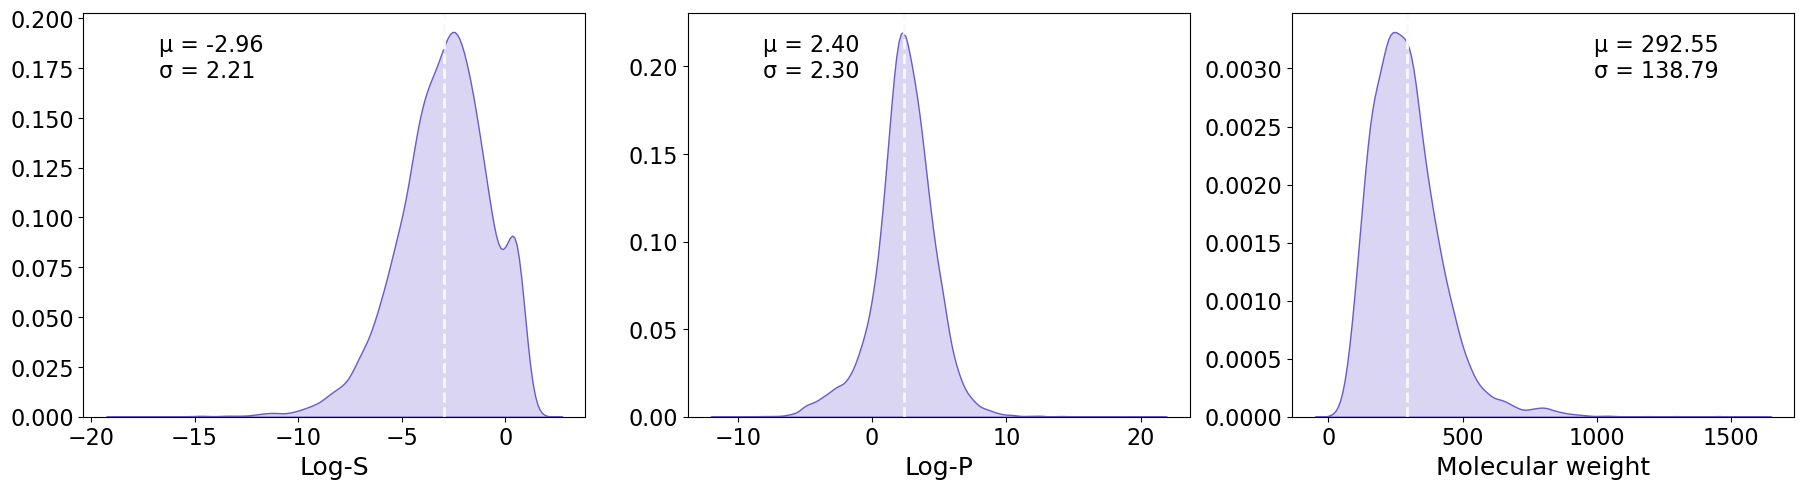

In [16]:
variables = ["logS", "logP", "MW"]

vars_names = {"logS": "Log-S",
              "logP": "Log-P",
              "MW": "Molecular weight"}

color="slateblue"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

for ax, var in zip(axes, variables):
    data = solubility_data_unique1[var].dropna()
    
    # KDE plot
    sns.kdeplot(data=data, fill=True, ax=ax, color=color)
    
    # Mean and SD
    mean = data.mean()
    std = data.std()
    
    # Mean line
    ax.axvline(mean, linestyle='--', linewidth=2, label=f"Mean: {mean:.2f}", color="ghostwhite")
    
    # ±1 SD region
    if (var=="MW"):
        ax.text(
        0.85, 0.95,
        f"μ = {mean:.2f}\nσ = {std:.2f}",
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=16)
    else:
        ax.text(
        0.15, 0.95,
        f"μ = {mean:.2f}\nσ = {std:.2f}",
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=16)

    
    
    # Labels
    ax.set_xlabel(vars_names[var], fontsize=18)
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=16)
    

plt.tight_layout()
plt.show()

### SOMAS solubility dataset

Gao, P., Andersen, A., Sepulveda, J. et al. SOMAS: a platform for data-driven material discovery in redox flow battery development. Sci Data 9, 740 (2022). https://doi.org/10.1038/s41597-022-01814-4

In [17]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import Descriptors

solubility_data2 = pd.read_csv(REPO_ROOT / "external" / "grover" / "solubility_data" / "somas_gao_et_al.csv")

duplicates_inchi = solubility_data2.duplicated(subset=["Standard InChIKey"])
print(f"Number of duplicated inchikeys: {duplicates_inchi.sum()}")

duplicates_smiles = solubility_data2.duplicated(subset=["SMILES"])
print(f"Number of duplicated SMILES: {duplicates_smiles.sum()}")

solubility_data_unique2 = solubility_data2.drop_duplicates(subset=["Standard InChIKey"], keep="first")
solubility_data_unique2 = solubility_data_unique2.drop_duplicates(subset=["SMILES"], keep="first")


print(f"Original rows: {len(solubility_data2)}")
print(f"Rows after removing duplicates: {len(solubility_data_unique2)}")

solubility_data_unique2["logS"] = np.log10(
    (solubility_data_unique2["Experimental Solubility in Water"] /
     solubility_data_unique2["Molar Mass"]) / 1000
)
solubility_data_unique2 = solubility_data_unique2.reset_index(drop=True)


Number of duplicated inchikeys: 0
Number of duplicated SMILES: 0
Original rows: 11692
Rows after removing duplicates: 11692


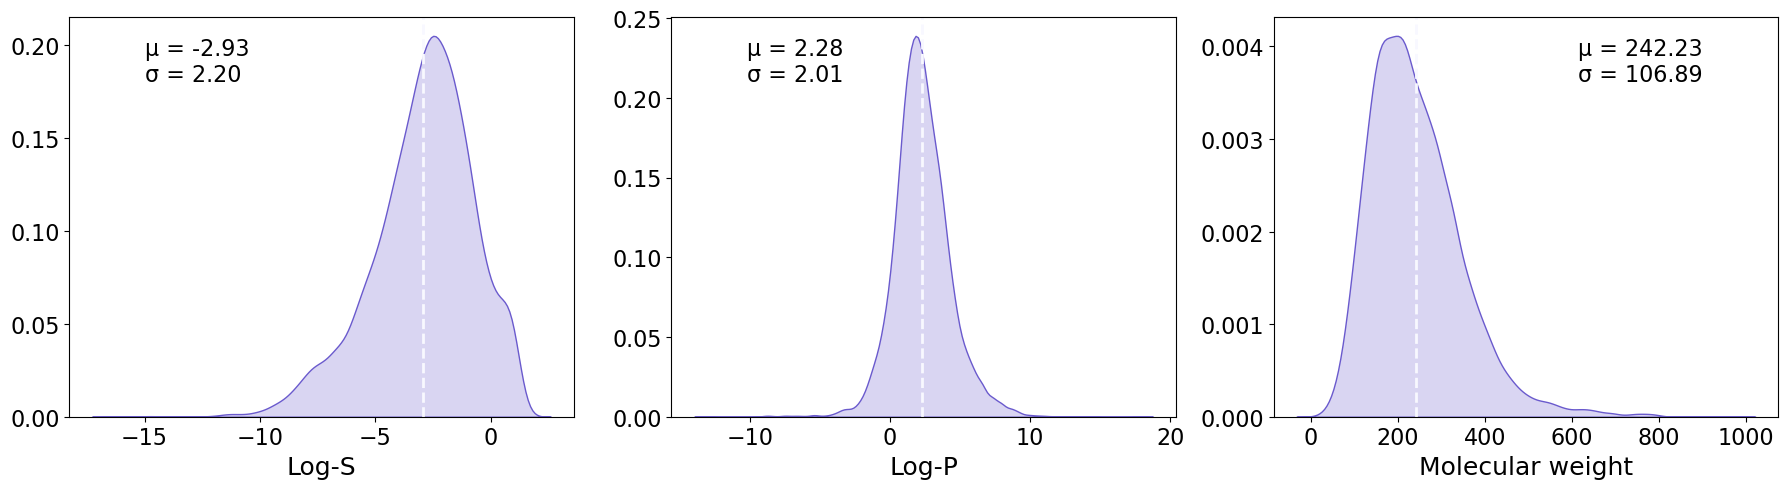

In [18]:
solubility_data_unique2 = solubility_data_unique2.rename(columns={
    "Molar Mass": "MW",
    "Cal logP": "logP",
    "Standard InChIKey": "InChIKey"
})

variables = ["logS", "logP", "MW"]

vars_names = {"logS": "Log-S",
              "logP": "Log-P",
              "MW": "Molecular weight"}

color="slateblue"

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 row, 3 columns

for ax, var in zip(axes, variables):
    data = solubility_data_unique2[var].dropna()
    
    # KDE plot
    sns.kdeplot(data=data, fill=True, ax=ax, color=color)
    
    # Mean and SD
    mean = data.mean()
    std = data.std()
    
    # Mean line
    ax.axvline(mean, linestyle='--', linewidth=2, label=f"Mean: {mean:.2f}", color="ghostwhite")
    
    # ±1 SD region
    if (var=="MW"):
        ax.text(
        0.85, 0.95,
        f"μ = {mean:.2f}\nσ = {std:.2f}",
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=16)
    else:
        ax.text(
        0.15, 0.95,
        f"μ = {mean:.2f}\nσ = {std:.2f}",
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=16)

    
    
    # Labels
    ax.set_xlabel(vars_names[var], fontsize=18)
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=16)
    

plt.tight_layout()
plt.show()

### Data preparation for training

Number of duplicated inchikeys: 5611
Number of duplicated SMILES: 4074
Original rows: 21633
Rows after removing duplicates: 16022


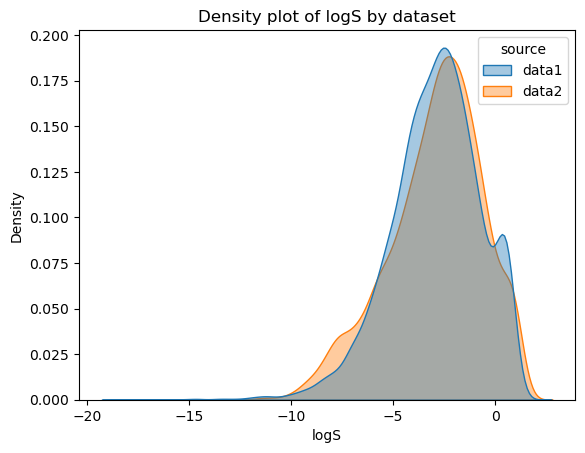

In [19]:
solubility_data_unique1['source'] = 'data1'
solubility_data_unique2['source'] = 'data2'

combined_dataset = pd.concat([solubility_data_unique1, solubility_data_unique2]).reset_index(drop=True)

duplicates_inchi = combined_dataset.duplicated(subset=["InChIKey"])
print(f"Number of duplicated inchikeys: {duplicates_inchi.sum()}")

duplicates_smiles = combined_dataset.duplicated(subset=["SMILES"])
print(f"Number of duplicated SMILES: {duplicates_smiles.sum()}")

solubility_data_unique = combined_dataset.drop_duplicates(subset=["InChIKey"], keep="first")
solubility_data_unique = solubility_data_unique.drop_duplicates(subset=["SMILES"], keep="first")

solubility_data_unique = solubility_data_unique.reset_index(drop=True)

print(f"Original rows: {len(combined_dataset)}")
print(f"Rows after removing duplicates: {len(solubility_data_unique)}")

sns.kdeplot(
    data=solubility_data_unique,
    x='logS',
    hue='source',
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title('Density plot of logS by dataset')
plt.show()

In [20]:
solubility_data_unique[['SMILES', 'logS']].to_csv(REPO_ROOT / "external" / "grover" / "solubility_data" / "solubility_data.csv", index=False)